## Study the effects of Ih currents on neuronal excitability

Authors: Armando Romani, Darshan Mandge, Open Brain Institute

Last Modified: 05.2026

This notebook was initially developed by Darshan Mandge for a [webinar](https://www.youtube.com/watch?v=MSl16e9B7qY) on single cell with only minor adjustments.
The notebook analyzes the impact of a change in the Ih current as reported in Alzheimer's disease mouse models [(Zhang et al., 2025)](https://link.springer.com/article/10.1186/s13195-025-01704-y).
Two simulations were run in advance, in control and mutation conditions, where the latter has the maximum Ih conductance reduced by 50%.

Let's first import some libraries:

In [1]:
from obi_auth import get_token
from entitysdk.client import Client
from entitysdk.common import ProjectContext
from entitysdk.models import Simulation, SimulationCampaign, SimulationResult, SimulationExecution
from obi_auth import get_token
from obi_notebook.get_projects import get_projects
from obi_notebook.get_environment import get_environment
from ipywidgets import widgets
from uuid import UUID
from campaign_helpers import stage_sim_campaign
import json

## Get authentication token and choose a project context

In [2]:
env = "staging"
token = get_token(environment=env, auth_mode="daf")
project_context = get_projects(token=token, env=env)

Device Authentication Required

1. Click on authentication URL
2. Complete authentication in browser
3. Return here when done

Authentication URL:
]8;id=13264364;https://staging.cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=FZHD-EPDY\https://staging.cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=FZHD-EPDY]8;;\

   ✓ Authentication completed successfully!


Dropdown(description='Select:', options=(('Test', {'id': 'cb164045-3415-437f-bf20-45e38ba9ac99', 'name': 'Test…

## Select SimulationCampaigns
Find and select simulation campaigns.

You should select two campaigns: one for control and one for mutation simulations.

In [3]:
# cortex
# control_id = UUID("e093ebf9-99fb-4874-83cc-57fd36ccfc8b")
# mulation_id = UUID("e089e891-30a1-4913-9d9b-3f0a7312239f")

# rat CA1
control_id = UUID("d88f96c4-7892-4dad-8947-c5399df981a9")
mulation_id = UUID("8a1fecfc-8ed3-4e31-854c-533ebb923e02")

In [4]:
client = Client(environment=env, project_context=project_context, token_manager=token)

mutation_sims = client.search_entity(entity_type=SimulationCampaign, query={
    "id": mulation_id, "authorized_project_id": project_context.project_id
}).all()
control_sims = client.search_entity(entity_type=SimulationCampaign, query={
    "id": control_id, "authorized_project_id": project_context.project_id
}).all()

sel_mutation = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in mutation_sims],
                                description="Mutation:")
sel_control = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in control_sims],
                                description="Control:")
display(widgets.HTML("Select control and mutation simulation campaigns:"))
display(sel_control)
display(sel_mutation)

HTML(value='Select control and mutation simulation campaigns:')

Dropdown(description='Control:', options=(('Healthy PC', UUID('d88f96c4-7892-4dad-8947-c5399df981a9')),), valu…

Dropdown(description='Mutation:', options=(('Healthy PC', UUID('8a1fecfc-8ed3-4e31-854c-533ebb923e02')),), val…

# Stage each SimulationCampaign

This downloads the simulation campaign data from the OBI platform into this notebook.

In [5]:
control_simulations = stage_sim_campaign(client, sel_control.value,
                                         output_dir=f"./simulation_results/{sel_control.value}")
mutation_simulations = stage_sim_campaign(client, sel_mutation.value,
                                          output_dir=f"./simulation_results/{sel_mutation.value}")

Let's do an interactive Control vs Mutation comparison

In [6]:
## Interactive Side-by-Side Control vs Mutation Comparison

# Import libraries for interactive widgets and plotting
from ipywidgets import interact

from campaign_helpers import get_percent_start
from plot_compare_traces import plot_comparison


# Build a mapping of percent_start to simulation paths
control_map = {
    get_percent_start(sim_path): sim_path for sim_path in control_simulations
}
mutation_map = {
    get_percent_start(sim_path): sim_path for sim_path in mutation_simulations
}

# Find common percent_start values between control and mutation
common_steps = sorted(set(control_map.keys()) & set(mutation_map.keys()))

# Create single dropdown for selecting stimulus step
step_dropdown = widgets.Dropdown(
    options=[(f"Step_{int(step)}", step) for step in common_steps],
    description='Stimulus:',
)

# Create the interactive interface
display(widgets.HTML(f"""Loaded {len(common_steps)} matching stimulus steps<br>
Available steps: {', '.join([f'Step_{int(s)}' for s in common_steps])}<br>
Use the dropdown menu above to select a stimulus step and compare control vs mutation"""))
interactive_plot_fun = plot_comparison(control_map, mutation_map)
interact(interactive_plot_fun, percent_start=step_dropdown)

HTML(value='Loaded 5 matching stimulus steps<br>\nAvailable steps: Step_100, Step_110, Step_120, Step_130, Ste…

interactive(children=(Dropdown(description='Stimulus:', options=(('Step_100', 100.0), ('Step_110', 110.0), ('S…

<function plot_compare_traces.plot_comparison.<locals>.plot_func_(percent_start)>

Let's compare first AP of the control and mutation simualtion campaigns.

In [7]:
## Interactive First AP Comparison (Figure 3C style)

from ipywidgets import interact

from plot_compare_ap_waveform import plot_first_ap_comparison

# Create interactive interface
display(widgets.HTML("Select a stimulus step from the dropdown above to compare first AP waveforms"))
interact(plot_first_ap_comparison(control_map, mutation_map), percent_start=step_dropdown)

HTML(value='Select a stimulus step from the dropdown above to compare first AP waveforms')

interactive(children=(Dropdown(description='Stimulus:', options=(('Step_100', 100.0), ('Step_110', 110.0), ('S…

<function plot_compare_ap_waveform.plot_first_ap_comparison.<locals>.plot_func_(percent_start)>

## Extract Features Using eFEL

Now we'll use eFEL to extract electrophysiological features from all simulations.

In [8]:
import pandas as pd
# Uses the eFEL library
from campaign_helpers import extract_features_from_simulation

# Extract features for all control simulations
print("Extracting features from control simulations...")
control_features = []
for i, sim_path in enumerate(control_simulations):
    features = extract_features_from_simulation(sim_path)
    features['campaign'] = 'control'
    features['sim_index'] = i
    control_features.append(features)
    print(f"  Control sim {i+1}: Step_{int(features['percent_start'])} - {features['spike_count']} spikes")

# Extract features for all mutation simulations
print("\nExtracting features from mutation simulations...")
mutation_features = []
for i, sim_path in enumerate(mutation_simulations):
    features = extract_features_from_simulation(sim_path)
    features['campaign'] = 'mutation'
    features['sim_index'] = i
    mutation_features.append(features)
    print(f"  Mutation sim {i+1}: Step_{int(features['percent_start'])} - {features['spike_count']} spikes")

# Combine into a DataFrame for easy analysis
all_features = control_features + mutation_features
features_df = pd.DataFrame(all_features)

# Sort by percent_start and campaign
features_df = features_df.sort_values(['percent_start', 'campaign'])

print("\n" + "="*60)
print("Feature Extraction Complete!")
print("="*60)
print(f"\nExtracted features from {len(control_features)} control and {len(mutation_features)} mutation simulations")
print("\nFeatures DataFrame:")
print(features_df.to_string(index=False))

Extracting features from control simulations...
  Control sim 1: Step_100 - 1 spikes


/Users/armando/Desktop/obi_platform_analysis_notebooks/.venv/lib/python3.14/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning: Error while calculating AHP_depth_abs_slow, An error occurred while computing the feature, feature is not found. At least 3 spikes needed for AHP_depth_abs_slow and AHP_slow_time.
  warnings.warn(
/Users/armando/Desktop/obi_platform_analysis_notebooks/.venv/lib/python3.14/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning: Error while calculating fast_AHP, Feature [fast_AHP] data is missing

  warnings.warn(


  Control sim 2: Step_110 - 1 spikes
  Control sim 3: Step_120 - 2 spikes
  Control sim 4: Step_130 - 9 spikes
  Control sim 5: Step_140 - 10 spikes

Extracting features from mutation simulations...
  Mutation sim 1: Step_120 - 1 spikes
  Mutation sim 2: Step_100 - 1 spikes
  Mutation sim 3: Step_110 - 1 spikes
  Mutation sim 4: Step_130 - 2 spikes
  Mutation sim 5: Step_140 - 8 spikes

Feature Extraction Complete!

Extracted features from 5 control and 5 mutation simulations

Features DataFrame:
 percent_start  stim_start  stim_end  spike_count  AP_half_width_mean  AHP_depth_abs_mean  fast_AHP_mean  AHP_depth_abs_slow_mean campaign  sim_index
         100.0         0.0    1000.0            1            1.300000          -69.324776            NaN                      NaN  control          0
         100.0         0.0    1000.0            1            1.325000          -70.090630            NaN                      NaN mutation          1
         110.0         0.0    1000.0            

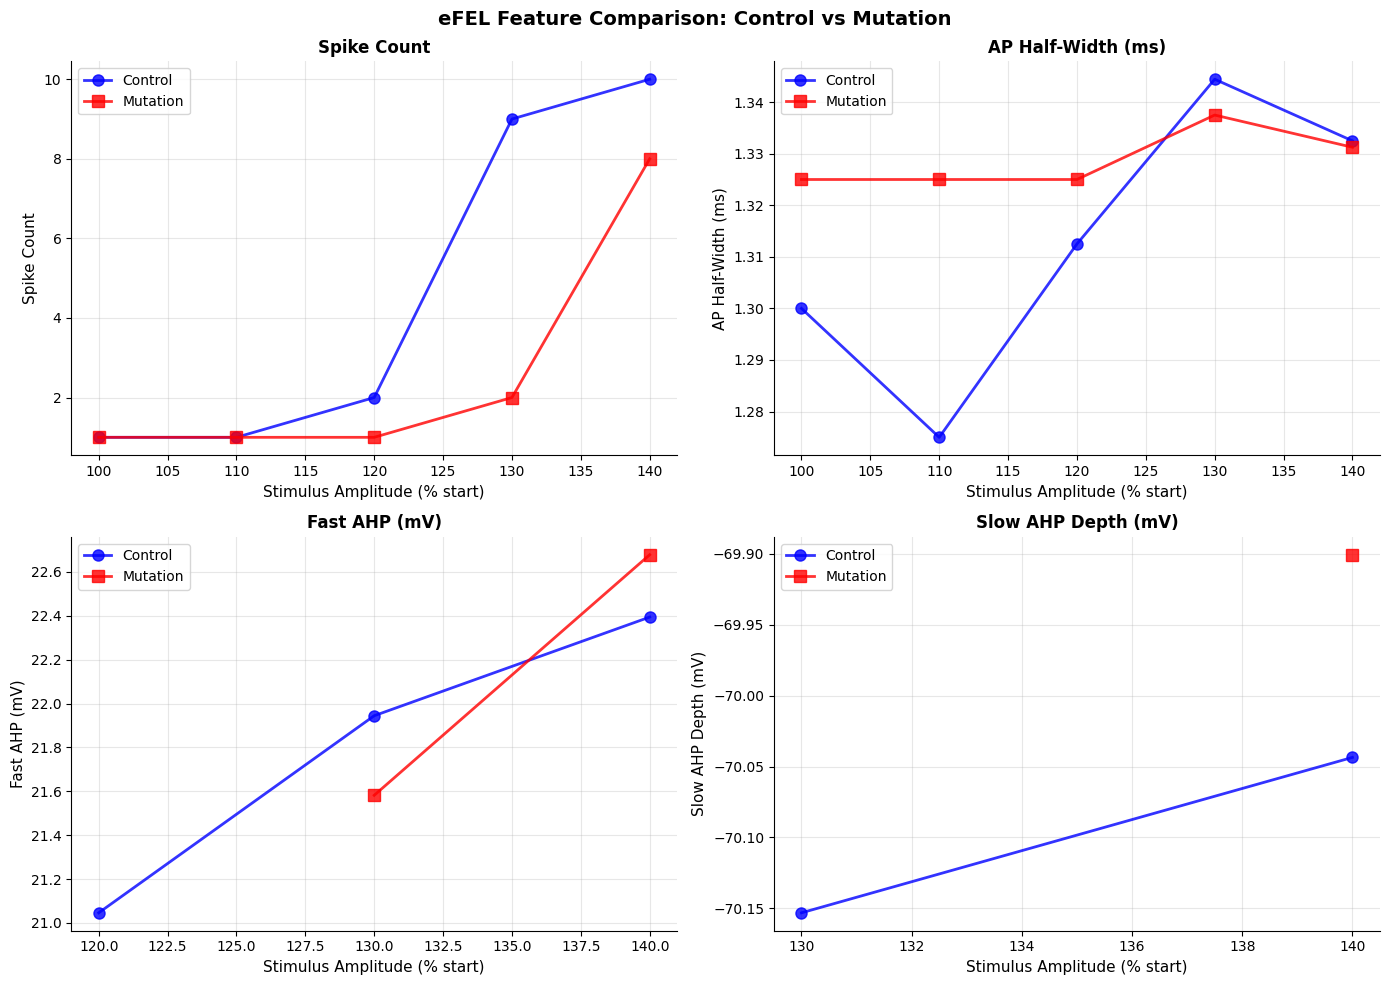


Feature Summary by Stimulus Amplitude:

Step_100:
  Spike Count:      Control=1, Mutation=1
  AP Half-Width:    Control=1.30 ms, Mutation=1.32 ms
  Fast AHP:         Control=nan mV, Mutation=nan mV
  Slow AHP Depth:   Control=nan mV, Mutation=nan mV

Step_110:
  Spike Count:      Control=1, Mutation=1
  AP Half-Width:    Control=1.28 ms, Mutation=1.32 ms
  Fast AHP:         Control=nan mV, Mutation=nan mV
  Slow AHP Depth:   Control=nan mV, Mutation=nan mV

Step_120:
  Spike Count:      Control=2, Mutation=1
  AP Half-Width:    Control=1.31 ms, Mutation=1.32 ms
  Fast AHP:         Control=21.05 mV, Mutation=nan mV
  Slow AHP Depth:   Control=nan mV, Mutation=nan mV

Step_130:
  Spike Count:      Control=9, Mutation=2
  AP Half-Width:    Control=1.34 ms, Mutation=1.34 ms
  Fast AHP:         Control=21.94 mV, Mutation=21.58 mV
  Slow AHP Depth:   Control=-70.15 mV, Mutation=nan mV

Step_140:
  Spike Count:      Control=10, Mutation=8
  AP Half-Width:    Control=1.33 ms, Mutation=1.33 ms

In [9]:
## Visualize Extracted Features

import matplotlib.pyplot as plt

# Create a figure with subplots for each feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Features to plot
features_to_plot = [
    ('spike_count', 'Spike Count'),
    ('AP_half_width_mean', 'AP Half-Width (ms)'),
    ('fast_AHP_mean', 'Fast AHP (mV)'),
    ('AHP_depth_abs_slow_mean', 'Slow AHP Depth (mV)')
]

# Plot each feature
for idx, (feature_name, feature_label) in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Get control and mutation data
    control_data = features_df[features_df['campaign'] == 'control']
    mutation_data = features_df[features_df['campaign'] == 'mutation']
    
    # Plot control
    ax.plot(control_data['percent_start'], control_data[feature_name], 
            'o-', color='blue', linewidth=2, markersize=8, label='Control', alpha=0.8)
    
    # Plot mutation
    ax.plot(mutation_data['percent_start'], mutation_data[feature_name], 
            's-', color='red', linewidth=2, markersize=8, label='Mutation', alpha=0.8)
    
    # Format plot
    ax.set_xlabel('Stimulus Amplitude (% start)', fontsize=11)
    ax.set_ylabel(feature_label, fontsize=11)
    ax.set_title(feature_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('eFEL Feature Comparison: Control vs Mutation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFeature Summary by Stimulus Amplitude:")
print("="*80)
for step in sorted(features_df['percent_start'].unique()):
    print(f"\nStep_{int(step)}:")
    control_row = features_df[(features_df['percent_start'] == step) & (features_df['campaign'] == 'control')].iloc[0]
    mutation_row = features_df[(features_df['percent_start'] == step) & (features_df['campaign'] == 'mutation')].iloc[0]
    
    print(f"  Spike Count:      Control={control_row['spike_count']:.0f}, Mutation={mutation_row['spike_count']:.0f}")
    
    if control_row['AP_half_width_mean'] is not None:
        print(f"  AP Half-Width:    Control={control_row['AP_half_width_mean']:.2f} ms, Mutation={mutation_row['AP_half_width_mean']:.2f} ms")
    
    if control_row['fast_AHP_mean'] is not None:
        print(f"  Fast AHP:         Control={control_row['fast_AHP_mean']:.2f} mV, Mutation={mutation_row['fast_AHP_mean']:.2f} mV")
    
    if control_row['AHP_depth_abs_slow_mean'] is not None:
        print(f"  Slow AHP Depth:   Control={control_row['AHP_depth_abs_slow_mean']:.2f} mV, Mutation={mutation_row['AHP_depth_abs_slow_mean']:.2f} mV")